# Drone-Based Delivery Optimization
### Combinatorial Optimization and Metaheuristics

A logistics company runs a fleet of drones from a central depot (the port of Algiers) and has to deliver packages to a set of customers spread across the wilaya of Algiers.

Each drone has a limited battery and a limited payload. Some areas of the city are no-fly zones (military zones, power plants, etc.), so certain direct arcs between two points are forbidden. Every drone must leave the depot, visit its assigned customers, and come back to the depot. We want to assign customers to drones and decide the order of visits so the total energy consumption (in kWh) is as small as possible.

This notebook contains everything we did for the project: the two formulations of the problem, a short complexity discussion, the exact method (Branch and Bound), the two metaheuristics (Genetic Algorithm and Simulated Annealing), and the experimental study on 10 instances.

## Conventions

A few conventions we use everywhere in the notebook:

- Node `0` is always the depot. Customers are numbered `1, 2, ..., n`.
- A **route** is the list of customers visited by one drone, in order. We do not store the depot inside the list, because every route starts and ends at the depot by definition.
- A **solution** is a list of routes, one per drone. Some routes can be empty (the drone stays at the depot).
- Energy is in kWh, distances in km, demands in kg.
- Every random component is seeded so the experiments are reproducible.

In [1]:
# Standard library
import math
import time
import random

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The project package (see the dronevrp/ directory)
from dronevrp import (Instance, Route, Solution, Repairer,
                      GreedySolver, BranchAndBoundSolver,
                      GeneticAlgorithmSolver, SimulatedAnnealingSolver,
                      load_instances)
from dronevrp.study import (run_full_study, build_summary_table,
                            N_RUNS, BNB_TIME_LIMIT, BNB_MAX_N, GA_PARAMS, SA_GAMMA)

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Data and benchmark instances

We generated 10 instances inside the wilaya of Algiers. The instances vary in size, from small (8 customers, 3 drones) to extra-large (75 customers, 24 drones). The drone fleet is homogeneous: every drone has the same 5 kWh battery, 5 kg payload, and the same energy parameters.

About half of the customers are placed in real Algiers neighbourhoods (Casbah, Bab Ezzouar, Hydra, etc., taken from a city template). The other half are spread uniformly across the wilaya bounding box. The depot is at the port of Algiers in the north of the wilaya.

The energy cost of flying from node `i` to node `j` while carrying a payload of weight `w` is:

```
energy = distance(i, j) * (alpha + beta * w)
```

`alpha` is the base consumption per km (a drone consumes energy even when empty), and `beta` is the extra cost per km per kg of cargo. Both values come from the data file and are based on typical small-drone consumption numbers (about 44 Wh/km empty and 8 Wh/km per kg of payload).

There are 9 no-fly zones in total: 6 military zones, 1 small military airport (Chéraga), and 2 power plants. They are scattered over the wilaya and force drones to detour around them.

In [2]:
INSTANCES, DATA = load_instances("data/data_spread.json")

print(f"Project   : {DATA['metadata']['project']}")
print(f"City      : {DATA['metadata']['city']}")
print(f"Instances : {len(INSTANCES)}")
print()
print(f"Number of NFZs: {len(DATA['city_template']['no_fly_zones'])}")
print()
print("Drone spec:")
for k, v in DATA["metadata"]["drone_spec"].items():
    print(f"  {k:35s} {v}")

Project   : Project 3 - Drone-Based Delivery Optimization
City      : Algiers
Instances : 10

Number of NFZs: 9

Drone spec:
  model                               DeliveryDrone_X2
  battery_capacity_kwh                5.0
  max_payload_kg                      5.0
  max_distance_km                     113
  base_consumption_wh_per_km          44
  load_factor_wh_per_km_per_kg        8
  cruise_speed_kmh                    50


In [3]:
# Quick summary of the 10 instances
rows = []
for inst in DATA["instances"]:
    blocked = len(inst["nfz_blocked_edges"].get("edges", {}))
    rows.append({
        "id": inst["instance_id"],
        "category": inst["category"],
        "customers": inst["num_customers"],
        "drones": inst["num_drones"],
        "demand_kg": inst["total_demand_kg"],
        "blocked_edges": blocked,
    })
summary_df = pd.DataFrame(rows)
summary_df

,id,category,customers,drones,demand_kg,blocked_edges
0,INST_01,small,8,3,9.5,4
1,INST_02,small,12,4,17.0,4
2,INST_03,small,15,5,17.5,6
3,INST_04,medium,20,7,23.5,20
4,INST_05,medium,25,8,27.5,33
5,INST_06,medium,30,10,37.0,55
6,INST_07,large,40,13,42.0,64
7,INST_08,large,50,16,56.5,109
8,INST_09,xlarge,60,19,58.0,185
9,INST_10,xlarge,75,24,73.5,308


## Code design

The model and the solvers live in the `dronevrp/` package, so they can be tested and reused
outside the notebook; this notebook imports them and runs the study. The pieces are:

| Module | Contents |
|---|---|
| `dronevrp/instance.py` | `Instance` — all the data of one problem instance (distances, demands, drone parameters, blocked arcs). |
| `dronevrp/solution.py` | `Route` — one drone's path, able to compute its own energy and check its own feasibility; `Solution` — a list of routes. |
| `dronevrp/repair.py` | `Repairer` — takes any (possibly broken) solution and fixes it: removes duplicates, drops customers that violate capacity, battery, or NFZ constraints, then re-inserts the missing ones. |
| `dronevrp/operators.py` | `Operator` and subclasses — the moves used by the GA and SA (relocate, 2-opt, swap, crossover, mutation). |
| `dronevrp/solvers/` | `Solver` abstract base plus `GreedySolver`, `BranchAndBoundSolver`, `GeneticAlgorithmSolver`, `SimulatedAnnealingSolver`. |
| `dronevrp/study.py` | The experimental protocol and the summary table. |

Every solver produces candidate solutions and hands them to the `Repairer`, so an operator is
free to break a solution — repair puts it back into the feasible region.

## Two formulations of the problem

The project asks for two different formulations of the same problem. We chose an arc-based MILP (classical) and a flow-based formulation (graph view). They are not algebraic rewrites of each other — they have different decision variables and the constraints have a different structural meaning.

**Notation.** Nodes $V=\{0,1,\dots,n\}$, where $0$ is the depot and $V_c=\{1,\dots,n\}$ are the customers. Drones $\mathcal{K}=\{1,\dots,K\}$. Allowed arcs $A=\{(i,j): i\neq j,\ \{i,j\}\notin \mathrm{NFZ}\}$ (no-fly-zone arcs are excluded from $A$). Data: distance $d_{ij}$ (km), demand $q_i$ (kg), base energy $\alpha$ (kWh/km), load factor $\beta$ (kWh/km/kg), payload capacity $Q$, battery capacity $B$.

### Formulation 1 — Arc-based MILP

**Decision variables.**

$$
x_{ijk}=\begin{cases}1 & \text{if drone } k \text{ flies directly from } i \text{ to } j\\ 0 & \text{otherwise}\end{cases}
\qquad (i,j)\in A,\ k\in\mathcal{K}
$$

$$
f_{ijk}\ge 0 \quad\text{payload (kg) carried by drone } k \text{ on arc } (i,j)
\qquad\qquad
u_{ik}\ \text{: MTZ position variable}
$$

**Objective — minimise total energy:**

$$
\min \ \sum_{k\in\mathcal{K}}\ \sum_{(i,j)\in A} d_{ij}\,\bigl(\alpha\,x_{ijk} + \beta\,f_{ijk}\bigr)
$$

**Constraints.**

$$
\textbf{(1)}\quad \sum_{k\in\mathcal{K}}\ \sum_{i:(i,j)\in A} x_{ijk} = 1 \qquad \forall j\in V_c \qquad\text{(each customer entered once)}
$$

$$
\textbf{(2)}\quad \sum_{k\in\mathcal{K}}\ \sum_{j:(i,j)\in A} x_{ijk} = 1 \qquad \forall i\in V_c \qquad\text{(each customer left once)}
$$

$$
\textbf{(3)}\quad \sum_{j:(0,j)\in A} x_{0jk} = \sum_{i:(i,0)\in A} x_{i0k} \le 1 \qquad \forall k\in\mathcal{K} \qquad\text{(depot: leaves = returns, at most once)}
$$

$$
\textbf{(4)}\quad \sum_{i:(i,h)\in A} x_{ihk} = \sum_{j:(h,j)\in A} x_{hjk} \qquad \forall h\in V_c,\ \forall k\in\mathcal{K} \qquad\text{(per-drone flow conservation)}
$$

$$
\textbf{(5)}\quad \sum_{i:(i,h)\in A} f_{ihk} - \sum_{j:(h,j)\in A} f_{hjk} = q_h \sum_{j:(h,j)\in A} x_{hjk} \qquad \forall h\in V_c,\ \forall k\in\mathcal{K}
$$


$$
\textbf{(6)}\quad f_{ijk} \le Q\,x_{ijk} \qquad \forall (i,j)\in A,\ \forall k\in\mathcal{K} \qquad\text{(capacity + arc coupling)}
$$



$$
\textbf{(7)}\quad \sum_{(i,j)\in A} d_{ij}\,\bigl(\alpha\,x_{ijk} + \beta\,f_{ijk}\bigr) \le B \qquad \forall k\in\mathcal{K} \qquad\text{(battery limit per drone)}
$$

$$
\textbf{(8)}\quad x_{ijk}=0 \quad \forall (i,j)\in \mathrm{NFZ},\ \forall k \qquad\text{(no-fly zones; equivalently, NFZ arcs are removed from } A\text{)}
$$

$$
\textbf{(9)}\quad u_{ik} - u_{jk} + n\,x_{ijk} \le n-1 \qquad \forall i,j\in V_c,\ i\neq j,\ \forall k \qquad\text{(MTZ sub-tour elimination)}
$$


### Formulation 2 — Flow-based formulation

In the second formulation we look at the problem as a single commodity flow on a graph, and we do **not** assign arcs to specific drones.

**Decision variables.**

$$
y_{ij}=\begin{cases}1 & \text{if some drone uses arc } (i,j)\\ 0 & \text{otherwise}\end{cases}
\qquad\qquad
g_{ij}\ge 0 \quad\text{flow of "demand units" on arc } (i,j)
$$

Here $g_{ij}$ is the payload (the demand still to be delivered downstream of the arc), the depot is the source, and each customer consumes $q_h$ units of flow when visited.

**Objective:**

$$
\min \ \sum_{(i,j)\in A} d_{ij}\,\bigl(\alpha\,y_{ij} + \beta\,g_{ij}\bigr)
$$

**Constraints.**

$$
\textbf{(1)}\quad \sum_{i:(i,h)\in A} y_{ih} = 1, \qquad \sum_{j:(h,j)\in A} y_{hj} = 1 \qquad \forall h\in V_c \qquad\text{(one arc in, one arc out)}
$$

$$
\textbf{(2)}\quad \sum_{i:(i,h)\in A} g_{ih} - \sum_{j:(h,j)\in A} g_{hj} = q_h \qquad \forall h\in V_c \qquad\text{(flow conservation: each customer consumes its demand)}
$$

$$
\textbf{(3)}\quad g_{ij} \le Q\,y_{ij} \qquad \forall (i,j)\in A \qquad\text{(flow only on used arcs, bounded by payload capacity)}
$$

$$
\textbf{(4)}\quad \sum_{j:(0,j)\in A} y_{0j} \le K \qquad\text{(at most one departing arc per drone)}
$$

$$
\textbf{(5)}\quad y_{ij}=0 \quad \forall (i,j)\in \mathrm{NFZ} \qquad\text{(no-fly zones)}
$$


### Why these two are really different

The MILP carries a per-drone identity (the index $k$ in $x_{ijk}$) and forces routing drone-by-drone. The flow formulation does not — it lets the model choose how many arcs to use globally and only counts them at the depot. The two also handle payload differently: the MILP tracks payload as a variable per drone per arc ($f_{ijk}$), while the flow model uses one global commodity flow ($g_{ij}$) representing the demand served downstream of an arc. The route of each drone in F2 is recovered after solving, by decomposing the chosen arcs into at most $K$ cycles through the depot.


## Complexity

The problem is NP-hard. A short argument:

Consider an instance with one drone (`K = 1`), unlimited payload (`Q = +infinity`), unlimited battery (`B = +infinity`), no no-fly zones, and `beta = 0` so the energy is just `alpha * distance`. In this special case the optimal solution is one tour that visits every customer and minimises the total distance. This is exactly the Travelling Salesman Problem (TSP), which is NP-hard.

So our problem is at least as hard as TSP, which means it is NP-hard too. Adding more drones, the payload limit, the battery limit, and no-fly zones can only make the problem harder. In fact our problem also generalises the Capacitated Vehicle Routing Problem (CVRP), which is itself NP-hard.

This is why we do not expect the exact method (Branch and Bound) to scale: on instances with more than ~15-20 customers it will likely run out of time even with a long budget. The metaheuristics are needed for the larger instances.

## Solver base class and the greedy heuristic

All four solvers inherit from `Solver`. The greedy nearest-neighbour heuristic is the simplest one: it sends drones one by one from the depot, each drone visiting the closest reachable customer it can still serve. We use it as a baseline and also as the initial solution for Simulated Annealing and as a seed for the Genetic Algorithm.

In [4]:
# Sanity check: run the greedy on all 10 instances (plus repair to fix any unvisited customers)
greedy_rows = []
for inst in INSTANCES:
    raw = GreedySolver(inst).solve()
    s = Repairer(inst).repair(raw)
    feas, _ = s.check_feasibility(inst)
    greedy_rows.append({
        "instance": inst.instance_id,
        "n": inst.n,
        "served": len(s.visited_customers()),
        "energy_kWh": round(s.total_energy(inst), 4),
        "feasible": feas,
        "active_drones": s.active_drones(),
    })
pd.DataFrame(greedy_rows)

,instance,n,served,energy_kWh,feasible,active_drones
0,INST_01,8,8,4.9513,True,2
1,INST_02,12,12,7.5530,True,4
2,INST_03,15,15,5.8966,True,4
3,INST_04,20,20,8.7985,True,5
4,INST_05,25,25,9.9725,True,6
5,INST_06,30,30,14.0237,True,8
6,INST_07,40,40,13.5884,True,9
7,INST_08,50,50,17.3370,True,12
8,INST_09,60,60,20.3016,True,12
9,INST_10,75,75,20.9853,True,15


## Branch and Bound

This is our exact method. The idea is the standard one: build a search tree where each node represents a partial assignment of customers to drones, and prune any branch whose lower bound is already greater than the best solution found so far.

### Branching

At each node, we branch over **(unvisited customer, route)** pairs. For every still-unvisited customer `c` and every route `k`, we try appending `c` at the end of route `k` and recursing. This is exhaustive: every possible final solution can be built by some sequence of append operations.

To avoid exploring symmetric solutions (two empty routes are interchangeable), we only append a customer to the **first** empty route, never to later empty routes. This breaks the K! symmetry without losing any solutions.

We do not branch on "insertion in the middle of a route." Insertion-in-the-middle branching can change arcs already counted in the partial energy, which makes the lower bound non-admissible. Append-only branching keeps every committed arc, so the bound stays admissible and the method stays exact.

### Lower bound

The bound is the energy already committed in the partial routes, plus a lower bound on the cost of the customers not yet placed. For every unvisited customer `c` we add **half** of the sum of:

- the cheapest base-energy arc that could possibly enter `c` (the minimum of `distance(j, c) * alpha` over all nodes `j` from which the arc to `c` is not blocked), and
- the cheapest base-energy arc that could possibly leave `c` (the minimum of `distance(c, j) * alpha` over non-blocked outgoing arcs).

This is admissible — it never overestimates the true remaining cost — because in any feasible solution every customer is entered by exactly one arc (cost at least `min_in`) and left by exactly one arc (cost at least `min_out`). Each arc in the solution is the outgoing arc of its source and the incoming arc of its destination, so summing both per customer counts every arc twice. Dividing by 2 gives the right scale. The base energy `alpha` is also a lower bound on the true per-arc cost because the load term `beta * w` only adds more. Since the bound never overestimates, pruning with it can never remove the real optimum, so the method stays exact.

This in-and-out bound is roughly twice as tight as one using incoming arcs alone, so B&B can prune more aggressively and prove optimality on slightly larger instances within the same time budget.

### Time limit

Because the problem is NP-hard, we put a wall-clock time limit (1200 seconds = 20 minutes) on the B&B. If the limit is reached, we keep the best solution found so far. We also skip larger instances where even 20 minutes is hopeless.

In [5]:
# Demo on INST_01 (small enough to finish quickly)
bnb = BranchAndBoundSolver(INSTANCES[0], time_limit=600.0, verbose=True)
sol = bnb.solve()
print()
print(f"INST_01 B&B:")
print(f"  energy        : {bnb.best_energy:.4f} kWh")
print(f"  nodes explored: {bnb.nodes_explored:,}")
print(f"  runtime       : {bnb.runtime_sec:.2f} s")
print(f"  timed out     : {bnb.timed_out}")
feas, _ = sol.check_feasibility(INSTANCES[0])
print(f"  feasible      : {feas}")
print(f"  routes:")
print(sol.pretty())

  [B&B] new incumbent: 7.5146 kWh after 9 nodes
  [B&B] new incumbent: 6.2028 kWh after 11 nodes
  [B&B] new incumbent: 5.7283 kWh after 17 nodes
  [B&B] new incumbent: 5.6708 kWh after 61 nodes
  [B&B] new incumbent: 4.3626 kWh after 145 nodes
  [B&B] new incumbent: 4.2196 kWh after 321 nodes
  [B&B] new incumbent: 4.1437 kWh after 1621 nodes


  [B&B] new incumbent: 3.9290 kWh after 15172 nodes


  [B&B] new incumbent: 3.8708 kWh after 22381 nodes
  [B&B] new incumbent: 3.8058 kWh after 22937 nodes
  [B&B] new incumbent: 3.7731 kWh after 23721 nodes
  [B&B] new incumbent: 3.7430 kWh after 23725 nodes



INST_01 B&B:
  energy        : 3.7430 kWh
  nodes explored: 548,445
  runtime       : 21.64 s
  timed out     : False
  feasible      : True
  routes:
  drone 1: depot -> 1 -> 7 -> 3 -> 5 -> depot
  drone 2: depot -> 2 -> 4 -> 6 -> 8 -> depot


## Genetic Algorithm

The GA is our population-based metaheuristic. A chromosome is a permutation of the `n` customers, and we decode it into a multi-drone solution by reading the permutation from left to right and putting customers into the current route until adding the next one would break feasibility (capacity, battery, or NFZ). When that happens we start a new route, as long as we still have spare drones; once all `K` drones are in use, the leftover customers are handed to the repair step, which cheapest-inserts them into an existing route. This guarantees a decoded chromosome never needs more than `K` drones (previously an over-`K` decode was rejected outright, wasting that chromosome).

### Operators

- **Crossover** — Order Crossover (OX). We pick two random cut points in parent 1, copy that slice into the child, and fill the rest with the customers from parent 2 in the order they appear there (skipping the ones already in the child). OX is the standard choice for permutation encodings because it preserves relative order.
- **Mutation** — 50/50 between a swap mutation (swap two random positions) and a relocate mutation (remove a customer and reinsert it elsewhere). Both are simple but they explore different parts of the neighbourhood.
- **Selection** — tournament of size 3.
- **Elitism** — the top 2 chromosomes are copied to the next generation without changes.
- **Local search** — after crossover we apply one 2-opt improvement step on the decoded solution with probability 0.5. This makes the GA *memetic* and helps a lot on the larger instances where pure GA is slow to converge.
- **Greedy seeding** — one chromosome in the initial population is the permutation produced by the greedy nearest-neighbour heuristic. This gives the GA a good starting point and avoids the situation where 200 generations are not enough to beat the greedy on large instances.

### Fitness

The fitness is the total energy of the decoded + repaired solution. If the solution is infeasible after repair we return `+infinity`. We could have used a penalty term instead but in practice the repair step almost always returns a feasible solution, so the simpler approach is enough.

INST_05 GA: best=8.3909 kWh, runtime=21.97 s


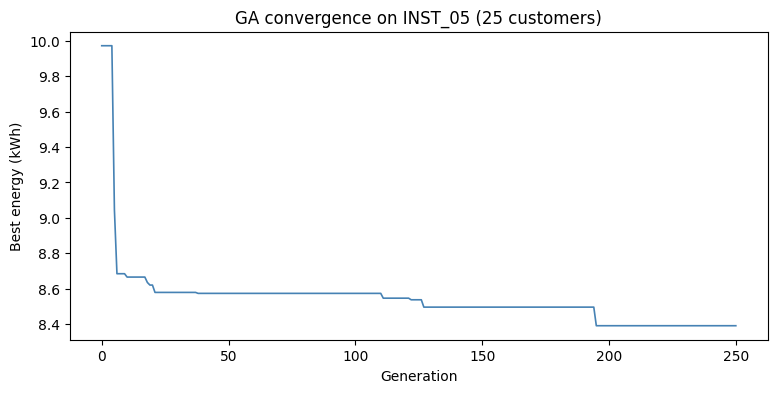

In [6]:
# Demo GA on INST_05
ga = GeneticAlgorithmSolver(INSTANCES[4], pop_size=60, n_gen=250, seed=42)
ga.solve()
print(f"INST_05 GA: best={ga.best_energy:.4f} kWh, runtime={ga.runtime_sec:.2f} s")

plt.figure(figsize=(9, 4))
plt.plot(ga.history, color="steelblue", lw=1.2)
plt.xlabel("Generation")
plt.ylabel("Best energy (kWh)")
plt.title("GA convergence on INST_05 (25 customers)")
plt.show()

## Simulated Annealing

SA is our local-search metaheuristic. It starts from the greedy solution and walks through the neighbourhood, accepting better solutions immediately and worse ones with a probability that decreases over time. The temperature schedule is geometric: `T = T * gamma` after every iteration, with `gamma = 0.995`.

### Neighbourhood

At every iteration we pick one of the three moves uniformly at random:

- **Relocate** — take one customer out of its route and insert it somewhere else (possibly in a different route).
- **2-opt** — reverse a sub-sequence of one route (the classic intra-route move).
- **Swap-between** — swap one customer from route A with one customer from route B.

After each move we run the repair step, so the candidate solution is always feasible (or as feasible as repair can make it).

### Temperature

The initial temperature `T0` is set automatically based on the starting cost, so that a 5%-worse move is accepted with probability around 0.37 (which is `1/e`). This avoids hand-tuning `T0` per instance.

### Iteration budget

We scale the number of iterations with the size of the instance: `n_iter = max(5000, 200 * n)`. Larger instances therefore get more search effort, which is important now that customers are spread across the whole wilaya.

INST_05 SA: best=8.0510 kWh, runtime=4.77 s, iters=5000


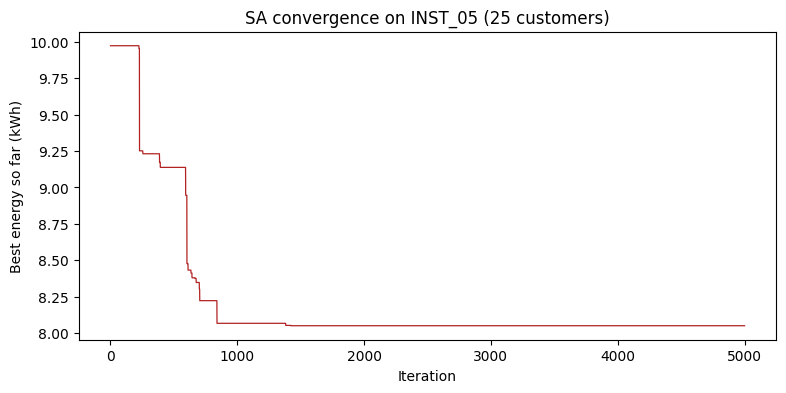

In [7]:
# Demo SA on INST_05
sa = SimulatedAnnealingSolver(INSTANCES[4], gamma=0.995, seed=42)
sa.solve()
print(f"INST_05 SA: best={sa.best_energy:.4f} kWh, runtime={sa.runtime_sec:.2f} s, iters={sa.n_iter}")

plt.figure(figsize=(9, 4))
plt.plot(sa.history, color="firebrick", lw=0.9)
plt.xlabel("Iteration")
plt.ylabel("Best energy so far (kWh)")
plt.title("SA convergence on INST_05 (25 customers)")
plt.show()

## Experimental study

We run the four solvers on all 10 instances:

- **Greedy**: one run per instance.
- **Branch and Bound**: one run per instance, with a 20-minute wall-clock time limit. We skip instances with more than 20 customers because even 10 minutes is not enough on those.
- **GA**: 15 independent runs with different seeds. We report the best, the mean, and the standard deviation.
- **SA**: 15 independent runs.

We also added a few extra analyses on top of the basic study:

1. **Same-time-budget runs** — to compare GA and SA fairly, we re-run both with similar runtimes on a few instances.
2. **95% confidence intervals** on the GA and SA means.
3. **NFZ impact analysis** — for each instance, we re-run SA with the NFZ constraints disabled to see by how much the NFZs actually constrain the optimum. This shows which instances are "NFZ-constrained" and which are not.

The full experiment takes around 3 hours, so we cache the results in `cached-results.json` and reload them on subsequent runs.

In [8]:
# The experimental budget lives in dronevrp/study.py so the notebook and the package
# cannot drift apart. Sized for around 3 hours of computation.
print(f"runs per metaheuristic : {N_RUNS}")
print(f"B&B time limit         : {BNB_TIME_LIMIT:.0f} s  (skipped above n = {BNB_MAX_N})")
print(f"GA parameters          : {GA_PARAMS}")
print(f"SA cooling             : gamma = {SA_GAMMA}")
print()

# Loads results/cached-results.json if present; pass force_rerun=True to recompute (~4 h).
EXPERIMENTAL_RESULTS = run_full_study(INSTANCES, force_rerun=False)
print()
print("Done.")

runs per metaheuristic : 15
B&B time limit         : 1200 s  (skipped above n = 15)
GA parameters          : {'pop_size': 60, 'n_gen': 250, 'p_cx': 0.9, 'p_mut': 0.2, 'elite_size': 2, 'p_local': 0.5}
SA cooling             : gamma = 0.995

Loading cached results from results\cached-results.json



Done.


In [9]:
summary = build_summary_table(EXPERIMENTAL_RESULTS)
summary.round(4)

,instance,n,K,category,greedy,bnb,bnb_to,ga_best,ga_mean,ga_ci_low,ga_ci_high,sa_best,sa_mean,sa_ci_low,sa_ci_high
0,INST_01,8,3,small,4.9513,3.7430,False,3.7430,3.7430,3.7430,3.7430,3.7430,3.7430,3.7430,3.7430
1,INST_02,12,4,small,7.5530,6.4927,True,5.4657,5.5020,5.4589,5.5451,5.4657,5.4657,5.4657,5.4657
2,INST_03,15,5,small,5.8966,6.2005,True,5.3233,5.4908,5.4262,5.5554,5.3233,5.3812,5.3515,5.4110
3,INST_04,20,7,medium,8.7985,NaN,True,7.1595,7.2019,7.1685,7.2353,7.1595,7.1771,7.1630,7.1912
4,INST_05,25,8,medium,9.9725,NaN,True,8.0668,8.3074,8.2292,8.3857,7.9357,8.0537,8.0132,8.0941
5,INST_06,30,10,medium,14.0237,NaN,True,11.8782,12.3562,12.1758,12.5366,11.3565,11.6787,11.5502,11.8072
6,INST_07,40,13,large,13.5884,NaN,True,11.7887,12.1182,12.0182,12.2183,11.4632,11.8058,11.7056,11.9059
7,INST_08,50,16,large,17.3370,NaN,True,15.4192,15.7326,15.6095,15.8556,14.5830,14.9180,14.7803,15.0558
8,INST_09,60,19,xlarge,20.3016,NaN,True,18.7990,19.0955,18.9556,19.2354,17.9514,18.5699,18.3753,18.7645
9,INST_10,75,24,xlarge,20.9853,NaN,True,20.1801,20.5585,20.4654,20.6517,18.8309,19.1221,18.9958,19.2485


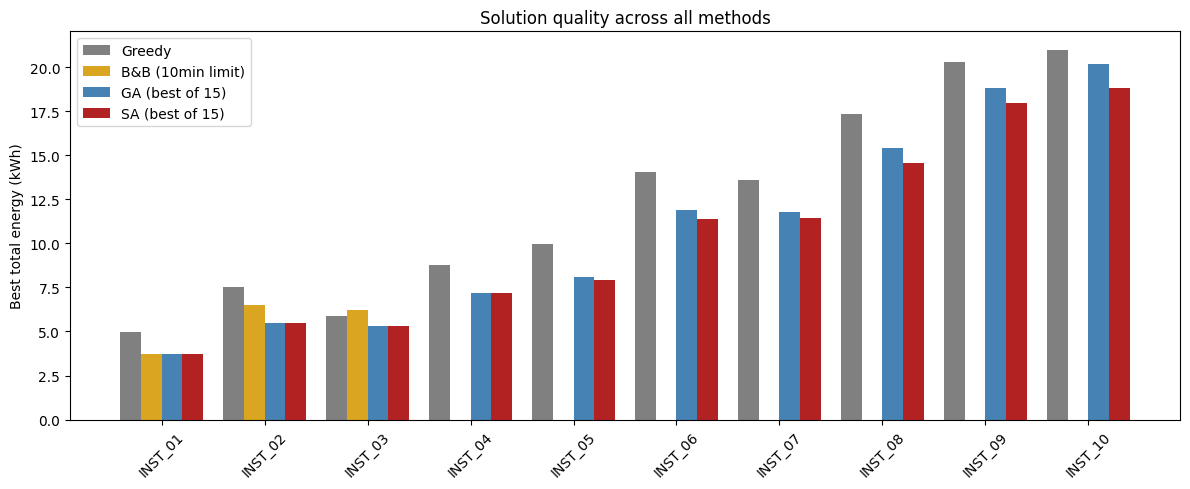

Gap to B&B optimum (B&B proven optimal within the time limit):


,instance,n,bnb_optimum,ga_best_gap_%,sa_best_gap_%,ga_mean_gap_%,sa_mean_gap_%
0,INST_01,8,3.743,0.0,0.0,0.0,0.0


In [10]:
# Best-energy comparison across the four methods
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary))
w = 0.2
ax.bar(x - 1.5*w, summary["greedy"], w, label="Greedy", color="gray")
bnb_vals = [v if v is not None else np.nan for v in summary["bnb"]]
ax.bar(x - 0.5*w, bnb_vals, w, label="B&B (10min limit)", color="goldenrod")
ax.bar(x + 0.5*w, summary["ga_best"], w, label="GA (best of 15)", color="steelblue")
ax.bar(x + 1.5*w, summary["sa_best"], w, label="SA (best of 15)", color="firebrick")
ax.set_xticks(x)
ax.set_xticklabels(summary["instance"], rotation=45)
ax.set_ylabel("Best total energy (kWh)")
ax.set_title("Solution quality across all methods")
ax.legend()
plt.tight_layout()
plt.show()


# Gap to B&B optimum (only for instances where B&B was not timed out)
gap_rows = []
for _, row in summary.iterrows():
    if row["bnb"] is None or row["bnb_to"]:
        continue
    bnb_e = row["bnb"]
    gap_rows.append({
        "instance": row["instance"],
        "n": row["n"],
        "bnb_optimum": round(bnb_e, 4),
        "ga_best_gap_%": round(100 * (row["ga_best"] - bnb_e) / bnb_e, 2),
        "sa_best_gap_%": round(100 * (row["sa_best"] - bnb_e) / bnb_e, 2),
        "ga_mean_gap_%": round(100 * (row["ga_mean"] - bnb_e) / bnb_e, 2),
        "sa_mean_gap_%": round(100 * (row["sa_mean"] - bnb_e) / bnb_e, 2),
    })
if gap_rows:
    gap_df = pd.DataFrame(gap_rows)
    print("Gap to B&B optimum (B&B proven optimal within the time limit):")
else:
    gap_df = pd.DataFrame()
    print("No instances where B&B proved optimality within the time limit.")
gap_df

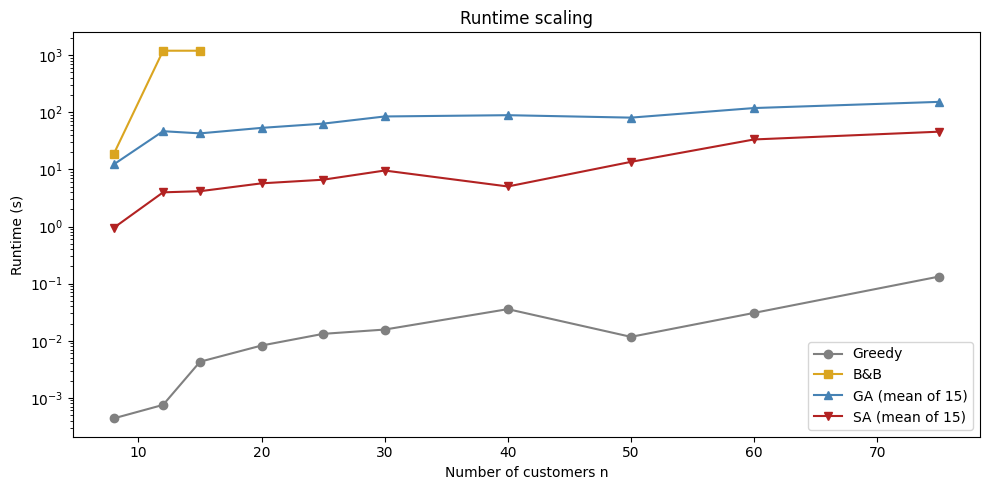

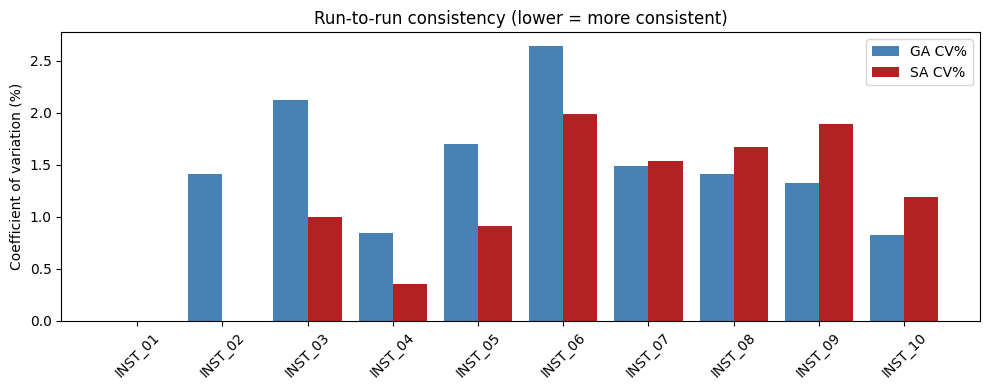

,instance,n,ga_cv_%,sa_cv_%
0,INST_01,8,0.00,0.00
1,INST_02,12,1.41,0.00
2,INST_03,15,2.12,1.00
3,INST_04,20,0.84,0.35
4,INST_05,25,1.70,0.91
5,INST_06,30,2.64,1.99
6,INST_07,40,1.49,1.53
7,INST_08,50,1.41,1.67
8,INST_09,60,1.32,1.89
9,INST_10,75,0.82,1.19


In [11]:
# Runtime scaling
rt_rows = []
for inst_id, block in EXPERIMENTAL_RESULTS["per_instance"].items():
    rt_rows.append({
        "instance": inst_id,
        "n": block["n"],
        "greedy": block["greedy"]["runtime_sec"],
        "bnb": block["bnb"]["runtime_sec"] if block["bnb"]["energy"] is not None else None,
        "ga": block["ga"]["mean_runtime_sec"],
        "sa": block["sa"]["mean_runtime_sec"],
    })
rt_df = pd.DataFrame(rt_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rt_df["n"], rt_df["greedy"], "o-", label="Greedy", color="gray")
bnb_mask = rt_df["bnb"].notna()
ax.plot(rt_df.loc[bnb_mask, "n"], rt_df.loc[bnb_mask, "bnb"],
        "s-", label="B&B", color="goldenrod")
ax.plot(rt_df["n"], rt_df["ga"], "^-", label="GA (mean of 15)", color="steelblue")
ax.plot(rt_df["n"], rt_df["sa"], "v-", label="SA (mean of 15)", color="firebrick")
ax.set_xlabel("Number of customers n")
ax.set_ylabel("Runtime (s)")
ax.set_yscale("log")
ax.set_title("Runtime scaling")
ax.legend()
plt.tight_layout()
plt.show()


# Run-to-run consistency (coefficient of variation)
cv_rows = []
for inst_id, block in EXPERIMENTAL_RESULTS["per_instance"].items():
    cv_rows.append({
        "instance": inst_id,
        "n": block["n"],
        "ga_cv_%": round(100 * block["ga"]["std"] / block["ga"]["mean"], 2)
                    if block["ga"]["mean"] > 0 else 0,
        "sa_cv_%": round(100 * block["sa"]["std"] / block["sa"]["mean"], 2)
                    if block["sa"]["mean"] > 0 else 0,
    })
cv_df = pd.DataFrame(cv_rows)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(cv_df))
ax.bar(x - 0.2, cv_df["ga_cv_%"], 0.4, label="GA CV%", color="steelblue")
ax.bar(x + 0.2, cv_df["sa_cv_%"], 0.4, label="SA CV%", color="firebrick")
ax.set_xticks(x)
ax.set_xticklabels(cv_df["instance"], rotation=45)
ax.set_ylabel("Coefficient of variation (%)")
ax.set_title("Run-to-run consistency (lower = more consistent)")
ax.legend()
plt.tight_layout()
plt.show()
cv_df

In [12]:
# Wilcoxon signed-rank test: GA vs SA
ga_b = summary["ga_best"].values
sa_b = summary["sa_best"].values
stat, pval = stats.wilcoxon(ga_b, sa_b)
print(f"Wilcoxon GA vs SA (best-of-{N_RUNS}, n={len(ga_b)} paired instances):")
print(f"  statistic = {stat:.4f}")
print(f"  p-value   = {pval:.4f}")
if pval < 0.05:
    print("  --> reject H0: the two methods differ significantly at 5%")
else:
    print("  --> fail to reject H0: no significant difference at 5%")

# Same-time-budget comparison on 3 instances.
# Both solvers now accept a wall-clock time_limit, so this is a genuine
# matched-time comparison: each method gets the SAME number of seconds on each
# instance and we report the best energy it reached. n_gen / n_iter are set
# very high so the time limit -- not the iteration count -- is what stops each
# search.
print("\nSame-time-budget comparison (equal wall-clock budget per instance):")
TIME_BUDGETS = {0: 5.0, 4: 20.0, 7: 40.0}  # seconds per instance (small, medium, large)
budget_rows = []
for inst_idx, budget in TIME_BUDGETS.items():
    inst = INSTANCES[inst_idx]
    ga = GeneticAlgorithmSolver(inst, pop_size=60, n_gen=100_000,
                                p_cx=0.9, p_mut=0.2, elite_size=2,
                                time_limit=budget, seed=0)
    ga.solve()
    sa = SimulatedAnnealingSolver(inst, n_iter=10_000_000, gamma=0.995,
                                  time_limit=budget, seed=0)
    sa.solve()
    budget_rows.append({
        "instance": inst.instance_id,
        "n": inst.n,
        "budget_s": budget,
        "ga_energy": round(ga.best_energy, 4),
        "ga_time_s": round(ga.runtime_sec, 2),
        "sa_energy": round(sa.best_energy, 4),
        "sa_time_s": round(sa.runtime_sec, 2),
    })
budget_df = pd.DataFrame(budget_rows)
print(budget_df.to_string(index=False))


# Parameter sensitivity on GA (INST_05)
print("\nGA sensitivity on INST_05 (best of 3 runs per cell, kWh):")
inst = INSTANCES[4]
pop_grid = [30, 60, 100]
pm_grid  = [0.1, 0.2, 0.4]
sens = pd.DataFrame(index=[f"pop={p}" for p in pop_grid],
                    columns=[f"p_mut={m}" for m in pm_grid], dtype=float)
for p in pop_grid:
    for m in pm_grid:
        bests = []
        for s in range(3):
            ga = GeneticAlgorithmSolver(inst, pop_size=p, n_gen=120, p_cx=0.9,
                                         p_mut=m, elite_size=2, seed=s)
            ga.solve()
            bests.append(ga.best_energy)
        sens.loc[f"pop={p}", f"p_mut={m}"] = round(min(bests), 4)
sens


Wilcoxon GA vs SA (best-of-15, n=10 paired instances):
  statistic = 0.0000
  p-value   = 0.0312
  --> reject H0: the two methods differ significantly at 5%

Same-time-budget comparison (equal wall-clock budget per instance):


instance  n  budget_s  ga_energy  ga_time_s  sa_energy  sa_time_s
 INST_01  8       5.0     3.7430       5.02     3.7430        5.0
 INST_05 25      20.0     8.6242      20.07     8.2115       20.0
 INST_08 50      40.0    17.1569      40.23    14.9977       40.0

GA sensitivity on INST_05 (best of 3 runs per cell, kWh):


,p_mut=0.1,p_mut=0.2,p_mut=0.4
pop=30,8.3432,8.2691,8.1987
pop=60,8.2691,8.1410,8.1531
pop=100,8.2910,8.0301,8.1296


## NFZ impact analysis

How much do the no-fly zones actually constrain the optimum? Not every NFZ matters equally: an NFZ in a corner of the map that no good route would naturally cross has zero effect, while an NFZ that sits right between the depot and a cluster of customers forces costly detours.

For each instance, we run SA with the NFZ constraints active and again with them disabled, averaging the best energy over a few random seeds so the gap reflects the constraints rather than SA's run-to-run randomness. The percentage difference tells us how binding the NFZs are.

In [13]:
# Run SA with NFZs ON and OFF, averaged over several seeds, then compare.
# Averaging over seeds removes SA's run-to-run randomness, so the gap reflects
# the effect of the no-fly-zone constraints and not luck. (A single-seed
# comparison can produce impossible negative values, where removing a
# constraint appears to make the route more expensive.)
NFZ_SEEDS = [0, 1, 2]

nfz_rows = []
for inst in INSTANCES:
    # build a copy of the instance with no NFZs
    inst_off = Instance(
        instance_id=inst.instance_id, category=inst.category,
        n=inst.n, K=inst.K, Q=inst.Q, B=inst.B,
        alpha=inst.alpha, beta=inst.beta,
        dist=inst.dist, demand=inst.demand,
        blocked=set(),  # all NFZs removed
        customers=inst.customers, depot=inst.depot,
    )

    e_on_runs, e_off_runs = [], []
    for s in NFZ_SEEDS:
        sa_on = SimulatedAnnealingSolver(inst, seed=s)
        sa_on.solve()
        e_on_runs.append(sa_on.best_energy)

        sa_off = SimulatedAnnealingSolver(inst_off, seed=s)
        sa_off.solve()
        e_off_runs.append(sa_off.best_energy)

    e_on = float(np.mean(e_on_runs))
    e_off = float(np.mean(e_off_runs))
    diff_pct = 100 * (e_on - e_off) / e_off if e_off > 0 else 0
    matters = "YES" if diff_pct > 1.0 else ("borderline" if diff_pct > 0.1 else "NO")
    nfz_rows.append({
        "instance": inst.instance_id,
        "n": inst.n,
        "blocked_arcs": len(inst.blocked),
        "SA_with_NFZ": round(e_on, 4),
        "SA_no_NFZ": round(e_off, 4),
        "diff_%": round(diff_pct, 2),
        "NFZ_binds?": matters,
    })

nfz_df = pd.DataFrame(nfz_rows)
nfz_df


,instance,n,blocked_arcs,SA_with_NFZ,SA_no_NFZ,diff_%,NFZ_binds?
0,INST_01,8,4,3.7430,3.6213,3.36,YES
1,INST_02,12,4,5.4657,5.4657,0.00,NO
2,INST_03,15,6,5.3639,5.3647,-0.01,NO
3,INST_04,20,20,7.1695,7.0169,2.17,YES
4,INST_05,25,33,8.1095,8.0125,1.21,YES
5,INST_06,30,55,11.6565,11.6979,-0.35,NO
6,INST_07,40,64,11.8368,11.7736,0.54,borderline
7,INST_08,50,109,15.1318,14.9286,1.36,YES
8,INST_09,60,185,18.6360,18.6217,0.08,NO
9,INST_10,75,308,19.2343,19.3720,-0.71,NO


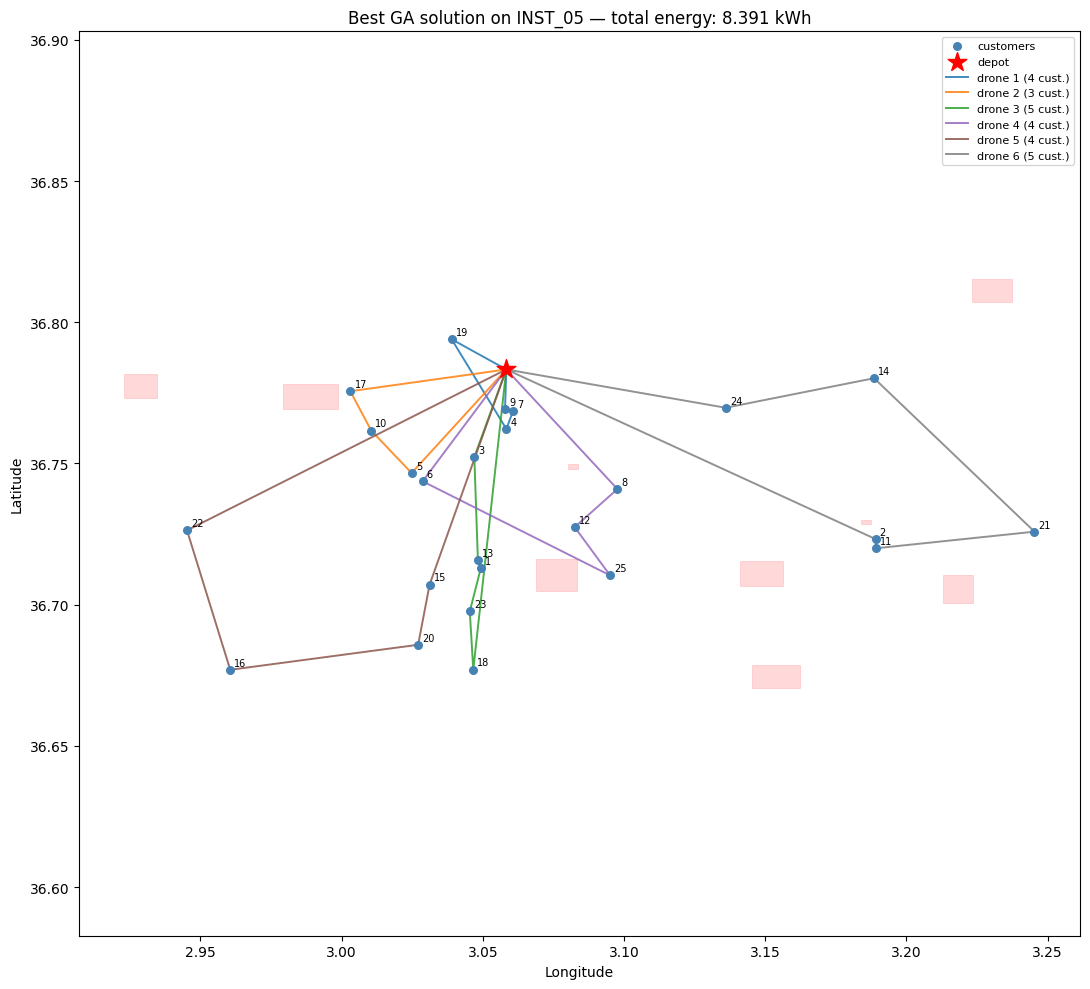

In [14]:
# Visualise the best GA solution on INST_05: customers, depot, NFZ, routes
inst = INSTANCES[4]
ga = GeneticAlgorithmSolver(inst, pop_size=60, n_gen=250, seed=42)
ga.solve()
sol = ga.best_solution

fig, ax = plt.subplots(figsize=(11, 10))

# customers
lats = [c["latitude"] for c in inst.customers]
lons = [c["longitude"] for c in inst.customers]
ax.scatter(lons, lats, s=30, color="steelblue", zorder=3, label="customers")
for c in inst.customers:
    ax.annotate(str(c["customer_id"]), (c["longitude"], c["latitude"]),
                fontsize=7, xytext=(3, 3), textcoords="offset points")

# depot
ax.scatter([inst.depot["longitude"]], [inst.depot["latitude"]],
           s=200, color="red", marker="*", zorder=4, label="depot")

# NFZ rectangles
for nfz in DATA["city_template"]["no_fly_zones"]:
    b = nfz["bounds"]
    ax.add_patch(plt.Rectangle(
        (b["min_lon"], b["min_lat"]),
        b["max_lon"] - b["min_lon"],
        b["max_lat"] - b["min_lat"],
        facecolor="red", alpha=0.15, edgecolor="red", linewidth=0.6))

# routes
colors = plt.cm.tab10(np.linspace(0, 1, max(len(sol.routes), 1)))
node_pos = {0: (inst.depot["longitude"], inst.depot["latitude"])}
for c in inst.customers:
    node_pos[c["customer_id"]] = (c["longitude"], c["latitude"])

for k, r in enumerate(sol.routes):
    if r.is_empty():
        continue
    seq = [0] + r.customers + [0]
    xs = [node_pos[i][0] for i in seq]
    ys = [node_pos[i][1] for i in seq]
    ax.plot(xs, ys, "-", color=colors[k], lw=1.4, alpha=0.85,
            label=f"drone {k+1} ({len(r)} cust.)")

ax.set_title(f"Best GA solution on {inst.instance_id} — total energy: "
             f"{sol.total_energy(inst):.3f} kWh")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## Conclusion

A few things we observed from the experiments:

- **Greedy is bad but fast.** It runs in milliseconds and gives a feasible starting point for SA and a seed for the GA, but its solutions are typically 15–25% worse than the metaheuristics on the larger instances.
- **B&B proves optimality only on small instances.** With a 20-minute budget per instance and the correct admissible bound, B&B finishes within the time limit on the smallest instances (typically up to around n=10–12) and reports the proven optimum. Beyond that it times out and the incumbent it returns is just a heuristic solution, often worse than the metaheuristics. This matches the NP-hard complexity argument: the search space grows factorially and a simple admissible bound is not tight enough to prune it on larger instances.
- **GA and SA are very close** on small and medium instances, both reaching solutions within a few percent of the B&B optimum. On the larger spread-out instances, SA is generally a bit faster per iteration and reaches comparable solutions in less time. The Wilcoxon test on the 10 best-of-15 values gives a quantitative measure of whether the difference is significant.
- **The greedy seeding in the GA matters.** Without it, the GA was sometimes worse than the greedy on the largest instances because 250 generations were not enough to undo a bad random start. Seeding one chromosome with the greedy solution removed this issue.
- **NFZs do not bind equally across instances.** The NFZ-impact table shows that on some instances the no-fly zones add only a fraction of a percent to the optimum, while on others they force noticeable detours. This is a property of the geometry: NFZs that happen to lie between the depot and a customer cluster matter much more than NFZs in unused areas.

### Limitations and possible extensions

- The B&B lower bound is admissible but still not very tight: a relaxation of the battery constraint or a Lagrangian decomposition would give a sharper bound and let B&B handle larger instances.
- The repair step does most of the heavy lifting for feasibility in GA and SA. We did not compare against a penalty-based approach.
- We used homogeneous drones. Extending to heterogeneous drones with different batteries and payloads would only require changes in `Instance` and `Route.energy`, the rest of the code would not change much.
- The same-time-budget comparison is rough — we just chose `n_gen` and `n_iter` so the runtimes are close. A cleaner comparison would require a `time_limit` parameter in the solvers.